# data pipline

In [18]:
import DataLoaderPipeline as dplmodule
from DataLoaderPipeline import DataLoaderPipeline
import importlib
importlib.reload(dplmodule)

<module 'DataLoaderPipeline' from 'c:\\Users\\ThinkPad\\Documents\\UNIVERSITY\\PFE2\\DataLoaderPipeline.py'>

In [ ]:
config = {
        "filtering_params": {
            "data_map_path": "data_maps/CASIA_FASD_v3_all.json",
        },

        "data_params": {
            "dataset_path": "data/CASIA_FASD_v3_224x224/DATA",
            "input_size": [224,224,3],
            "pixel_range": [0.0,1.0],
            "batch_size": 32,
            "validation_subjects_number": 0, # < 5 # Number of subjects to be used for validation (the will not be used for training)
            "get_random_subjects_for_validation": 0, # 1 for random selection, 0 for fixed selection (the first N subjects in the dataset)
            "validation_dataset_baleance": 0, # 0 for unbalanced, 1 for balanced
        },        
        
        "augmentation_params": {
            "rotation_range": 0.15,
            "horizontal_flip": 0,
            "brightness_delta": 0.1, # -1.0 to 1.0, 0 for no change
            "contrast_range": [0.9, 1.1], # [lower, upper], 1.0 for no change
            "zoom_range": 0.1
        },
        
        "model_params": {
            "model_init_function": None,
            "architecture": None,  # To be filled after model initialization
            "parameters_count": None  # To be filled after model initialization
                       
        },
        
        "training_params": {
            "early_stopping_patience": 5,
            "learning_rate": 0.0001,
            "initial_epochs": 1
        }      
    }


In [20]:
all_subjects = [f"{i:02d}" for i in range(1, 51)]  # Generate subject IDs from '01' to '50'.
train_subs = all_subjects[:15]
val_subs = all_subjects[15:20] 
test_subs = all_subjects[20:] 

dlp = DataLoaderPipeline(data_params=config["data_params"],
                         filtering_params=config["filtering_params"],
                         augmentation_params=config["augmentation_params"])


Successfully loaded 50 subjects from JSON.


In [21]:
dlp.build_pipeline(train_subs,True,True,True)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [22]:
dlp.audit_dataset(dlp.build_pipeline(train_subs,True,True,True), batchs=-1)

Auditing up to 1613 batches...

POST-CREATION DATASET AUDIT
Total Samples Audited: 51588
Real Samples:  25775 (50.0%)
Spoof Samples: 25813 (50.0%)
------------------------------
Pixel Range: [0.00 to 1.00]
Status: Normalization OK
Status: Balance OK (~50/50)



In [ ]:
dlp.audit_dataset(dlp.build_pipeline(val_subs,balanced=False,augment=False,shuffle=False), batchs=-1)

In [10]:
dlp.audit_dataset(dlp.build_pipeline(val_subs,balanced=True,augment=False,shuffle=False), batchs=-1)

In [7]:
dlp.audit_dataset(dlp.build_pipeline(test_subs,False,False), batchs=-1)

In [24]:
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

def visualize(original, augmented, cmap='gray'):
  fig = plt.figure()
  plt.subplot(1,2,1)
  plt.title('Original image')
  plt.imshow(original, cmap= cmap)

  plt.subplot(1,2,2)
  plt.title('Augmented image')
  plt.imshow(augmented, cmap= cmap)

In [67]:

real_img = cv2.imread("./data/CASIA_FASD_V3/DATA/01/real/01_01_001.jpg", cv2.IMREAD_COLOR_RGB)
plt.imshow(real_img)
plt.show()

spoof_img = cv2.imread("./data/CASIA_FASD_V3/DATA/01/spoof/01_03_001.jpg", cv2.IMREAD_COLOR_RGB)
plt.imshow(spoof_img)
plt.show()

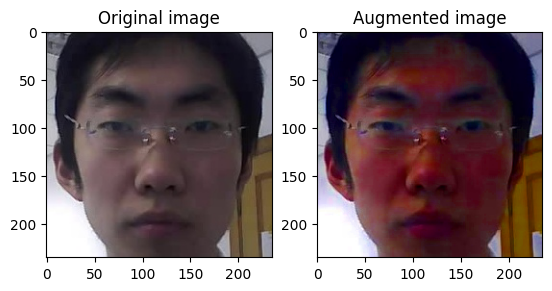

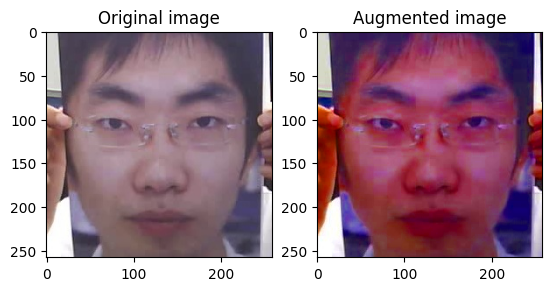

In [95]:
mod_real_img = tf.image.adjust_saturation(real_img, 3)
mod_spoof_img = tf.image.adjust_saturation(spoof_img, 3)

visualize(real_img, mod_real_img)
visualize(spoof_img, mod_spoof_img)